# PTA Likelihood vs Pulsar Distance — Realistic Noise

This notebook is a parallel version of `pta_likelihood_vs_distance.ipynb` with
two key differences:

1. **Non-uniform TOA spacing** — each pulsar is observed at random times
   (drawn from a Poisson-like process) rather than evenly spaced.
2. **Realistic noise** — each pulsar includes EFAC, EQUAD, ECORR, and
   power-law red noise in addition to the spindown timing model.

In [ ]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import pint.models as pm

from jaxpint.pta.likelihood import pta_logL
from jaxpint.notebook_utils import (
    build_cw_injectors,
    generate_random_par,
    inject_and_build_config,
    plot_1d_delta_logL,
    setup_synthetic_pta,
    sweep_1d_logL,
)

# ---- Configuration ----
N_PULSARS = 60
M_CW_SOURCES = 100
N_TOAS = 200              # approximate number per pulsar
GLOBAL_START_MJD = 55000.0
GLOBAL_END_MJD = 61000.0  # pulsars drawn from within this window
MIN_SPAN_DAYS = 1500.0    # minimum observation span per pulsar
TOA_ERROR = 1e-8           # 10 ns
FREQ = 1400.0              # MHz
SEED = 42


## Generate random pulsars with realistic noise

Each pulsar has EFAC, EQUAD, ECORR (white/correlated noise) and power-law
red noise (TNRedAmp, TNRedGam, TNRedC).

**Convention:** `PX` is parallax in mas (PINT / `types.py` convention).
`CWInjector` converts internally to distance via `L_kpc = 1 / PX_mas` for
the Ellis+2012 pulsar-term phase. Sweeps below iterate in mas; plots
display on a kpc axis via the same `1 / PX_mas` mapping.

In [ ]:
rng = np.random.default_rng(SEED)


def random_obs_window(rng):
    """Draw a random start/end MJD within the global window, with minimum span."""
    span = GLOBAL_END_MJD - GLOBAL_START_MJD
    start = rng.uniform(GLOBAL_START_MJD, GLOBAL_END_MJD - MIN_SPAN_DAYS)
    end = rng.uniform(start + MIN_SPAN_DAYS, min(start + span, GLOBAL_END_MJD))
    return start, end


obs_windows = [random_obs_window(rng) for _ in range(N_PULSARS)]
par_strings = [
    generate_random_par(
        idx, rng,
        start_mjd=s,
        noise="realistic",
        include_dm=True,
    )
    for idx, (s, _) in enumerate(obs_windows)
]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars with individual observation windows:")
for i, (s, e) in enumerate(obs_windows):
    print(f"  Pulsar {i}: MJD {s:.0f} – {e:.0f}  ({(e-s)/365.25:.1f} yr)")
print(f"\nExample .par:\n{par_strings[0]}")


## Generate non-uniform TOAs and convert to JaxPINT

In [ ]:
def generate_irregular_mjds(start, end, n_approx, rng):
    """Generate non-uniformly spaced MJDs using a Poisson-like process."""
    avg_gap = (end - start) / n_approx
    mjds = [start]
    while mjds[-1] < end:
        gap = rng.exponential(avg_gap)
        mjds.append(mjds[-1] + gap)
    mjds = np.array(mjds[:-1])
    return mjds[mjds < end]


mjds_per_pulsar = [
    generate_irregular_mjds(s, e, N_TOAS, rng)
    for (s, e) in obs_windows
]

synthetic = setup_synthetic_pta(
    pint_models,
    toa_error_s=TOA_ERROR, freq_mhz=FREQ,
    mjds_per_pulsar=mjds_per_pulsar,
)
toa_data_list = list(synthetic.toa_data_list)
pulsar_params_list = list(synthetic.pulsar_params_list)
timing_models = list(synthetic.timing_models)
noise_models = list(synthetic.noise_models)
base_toa_data_list = list(synthetic.toa_data_list)
pp_tuple = synthetic.pulsar_params_list

for i, (model, (s, e)) in enumerate(zip(pint_models, obs_windows)):
    n = toa_data_list[i].n_toas
    px_mas = float(pulsar_params_list[i].param_value("PX"))
    distance_kpc = 1.0 / px_mas
    print(
        f"  Pulsar {i}: {model.PSR.value:>20s}  n_toas={n:3d}  "
        f"MJD {s:.0f}–{e:.0f}  PX={px_mas:.3f} mas (d={distance_kpc:.2f} kpc)"
    )

print(f"\nAll {N_PULSARS} pulsars loaded.")

## Visualize TOA spacing

Show that the TOA cadence is irregular for each pulsar.

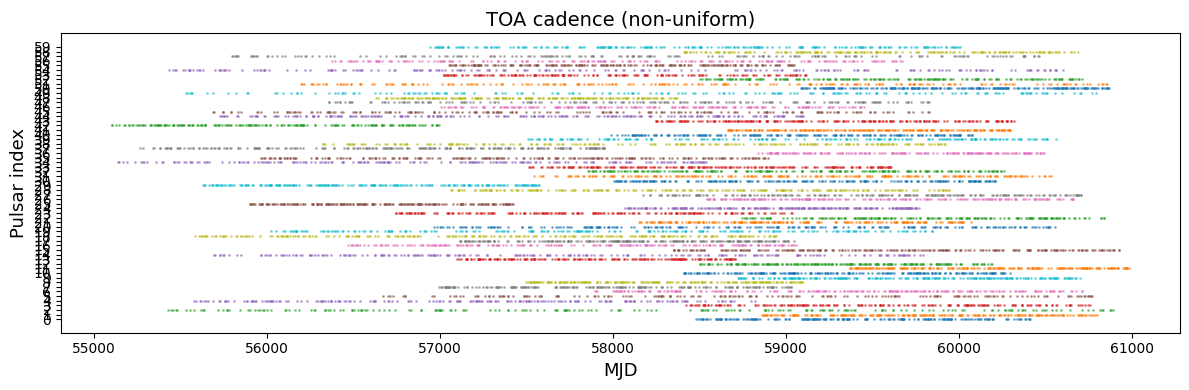

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
for i in range(N_PULSARS):
    mjds = np.array(toa_data_list[i].tdb_int + toa_data_list[i].tdb_frac)
    ax.scatter(mjds, np.full_like(mjds, i), s=1, alpha=0.5)
ax.set_xlabel("MJD", fontsize=13)
ax.set_ylabel("Pulsar index", fontsize=13)
ax.set_title("TOA cadence (non-uniform)", fontsize=14)
ax.set_yticks(range(N_PULSARS))
fig.tight_layout()
plt.show()

## Set up CW sources and PTA config

Same structure as the uniform-cadence notebook: each CW source gets a random
sky position and frequency.

In [ ]:
all_cw_injectors, positions = build_cw_injectors(
    pint_models, n_sources=M_CW_SOURCES, rng=rng, log10_h=-12.0,
)
all_cw_injectors = list(all_cw_injectors)

print(f"Generated {M_CW_SOURCES} CW sources")


## Sweep distance for pulsar 0

Same as the uniform notebook — sweep PX for the target pulsar across
different numbers of CW sources.

In [ ]:
TARGET_PULSAR = 0
true_px_mas = float(pp_tuple[TARGET_PULSAR].param_value("PX"))
true_distance = 1.0 / true_px_mas  # kpc
print(f"Pulsar {TARGET_PULSAR} true distance: {true_distance:.3f} kpc "
      f"(PX = {true_px_mas:.4f} mas)")

half_window = 0.005  # kpc (x-axis window in distance)
distance_grid = np.linspace(
    true_distance - half_window,
    true_distance + half_window,
    500,
)
px_mas_grid = 1.0 / distance_grid

M_values = [1, 2, 5, M_CW_SOURCES]
results = {}

for M in M_values:
    print(f"\n--- M = {M} CW source(s) ---")
    cw_subset = all_cw_injectors[:M]
    gp, cfg = inject_and_build_config(synthetic, cw_subset)

    def _eval(px_mas_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_mas_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    results[M] = sweep_1d_logL(_eval, px_mas_grid)
    print(f"  Sweep complete ({len(px_mas_grid)} points)")

print("\nAll sweeps done.")

## Plot Likelihood

In [ ]:
from jaxpint.fitters import WLSFitter
from jaxpint.types import ParameterVector

target_params = pp_tuple[TARGET_PULSAR]
px_idx = target_params.names.index("PX")
new_frozen = list(target_params.frozen_mask)
new_frozen[px_idx] = False
fit_params = ParameterVector(
    values=target_params.values,
    frozen_mask=tuple(new_frozen),
    names=target_params.names,
    units=target_params.units,
    epoch_int_values=target_params.epoch_int_values,
)

fitter = WLSFitter(
    timing_models[TARGET_PULSAR],
    base_toa_data_list[TARGET_PULSAR],
    fit_params,
    noise_models[TARGET_PULSAR],
)
fit_result = fitter.fit_toas()

free_names = [fit_params.names[i] for i in fit_params._free_indices]
px_free_idx = free_names.index("PX")
px_err_mas = float(fit_result.parameter_uncertainties[px_free_idx])
# d = 1 / PX, so sigma_d = |d(d)/d(PX)| * sigma_PX = d^2 * sigma_PX
px_err = px_err_mas * true_distance ** 2  # kpc

print(f"JaxPINT WLS fitter result for pulsar {TARGET_PULSAR}:")
print(
    f"  PX = {float(fit_result.params.param_value('PX')):.6f} +/- "
    f"{px_err_mas:.6f} mas (1-sigma)  ->  sigma_d = {px_err:.6f} kpc"
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.axvspan(
    true_distance - px_err, true_distance + px_err,
    alpha=0.15, color="gray", label=f"Fitter 1$\\sigma$ = {px_err:.4f} kpc",
)
for M in M_values:
    plot_1d_delta_logL(
        ax, distance_grid, results[M],
        label=f"M = {M} CW source{'s' if M > 1 else ''}",
    )
ax.axvline(
    true_distance, color="black", linestyle="--", linewidth=1.5,
    label=f"True distance = {true_distance:.2f} kpc",
)

view = 0.01
ax.set_xlim(true_distance - view, true_distance + view)
ax.set_xlabel("Pulsar distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA log-likelihood vs distance (non-uniform cadence, realistic noise)\n"
    f"({N_PULSARS} pulsars, {N_TOAS} TOAs each, varying number of CW sources)",
    fontsize=14,
)
ax.set_yscale("linear")
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()